# C2_baby_absent — 무라벨(라벨링 없이) 획득

Grounding DINO tiny 오픈보캐뷸러리 검출기에 "a baby. a person." 텍스트 프롬프트를 주어 클립당 균등 샘플링한 8프레임(2배 업스케일)에서 제로샷 검출을 수행한다. 프레임별 최고 검출 점수의 클립 통계(det_max, present_frac)로 아기 없음(1)/있음(0)/불확실(-1) 의사라벨을 부여한다. COCO 고정 클래스 YOLO person 보다 "a baby" 프롬프트가 240x136 저해상도·야간 IR·포대기 상황에서 더 강건하며, manifest의 mean_ydif(움직임)와 교차검증해 임계값을 점검한다. T4 기준 1000클립 x 8프레임 처리에 약 20분 수준이다.

In [2]:
# 공통 설정 — Drive 마운트 + 경로 + manifest
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd

BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, 'mp4 폴더 없음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), 'manifest.csv 를 BASE 에 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
man = pd.read_csv(BASE/'manifest.csv')
print('clips:', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 / manifest:', len(man))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
clips: /content/drive/MyDrive/BabyMon/dataset/clips 24080 개 / manifest: 24080


In [3]:
!pip install -q -U transformers av decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 98.3 MB/s eta 0:00:00


## C2_baby_absent — 아기 없음 자동 라벨링 (제로샷 오픈보캐뷸러리 검출)

**방법**: Grounding DINO(tiny)에 텍스트 프롬프트 `"a baby. a person."` 을 주어 클립당 균등 샘플 8프레임에서 제로샷 검출을 수행한다.

- 프레임별 최고 검출 점수 → 클립 통계 `det_max`, `det_mean`, `present_frac`(점수 ≥ 0.35 프레임 비율)
- 의사라벨 `absent_pseudo`: `det_max < 0.25` → **1 (아기 없음)**, `present_frac ≥ 0.5` → **0 (아기 있음)**, 그 외 → **-1 (불확실)**, 디코딩 실패 → **-9**
- COCO 고정 클래스(YOLO person)보다 "a baby" 프롬프트가 저해상도(240x136)·야간 IR 흑백·포대기 상황에 더 강건하다. 240x136 프레임은 2배(480x272) 업스케일 후 검출한다.
- 검증: manifest 의 `mean_ydif`(프레임간 휘도차)와 교차검증 — 아기 없음 클립은 움직임도 낮게 나와야 자연스럽다. 히스토그램을 보고 임계값(0.25/0.35)을 조정한다.

**출처**
- Grounding DINO: Marrying DINO with Grounded Pre-Training for Open-Set Object Detection (ECCV 2024) — https://arxiv.org/abs/2303.05499
- OWL-ViT: Simple Open-Vocabulary Object Detection with Vision Transformers (ECCV 2022, 대안 검출기) — https://arxiv.org/abs/2205.06230
- An Intelligent Baby Monitor with Automatic Sleeping Posture Detection and Notification (MDPI AI, 2021) — https://www.mdpi.com/2673-2688/2/2/18

In [4]:
# 모델 초기화: Grounding DINO tiny (제로샷 오픈보캐뷸러리 검출)
import torch
import numpy as np
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
GD_ID = 'IDEA-Research/grounding-dino-tiny'
processor = AutoProcessor.from_pretrained(GD_ID)
gd_model = AutoModelForZeroShotObjectDetection.from_pretrained(GD_ID).to(DEVICE).eval()

TEXT_PROMPT = 'a baby. a person.'  # Grounding DINO 규약: 소문자, 구문은 '.' 로 구분
TEXT_TH = 0.20      # 텍스트 매칭 임계값
PRESENT_TH = 0.35   # 프레임을 '아기 있음'으로 판정하는 검출 점수
ABSENT_TH = 0.25    # 클립 최대 점수가 이보다 낮으면 '아기 없음'
print('device:', DEVICE)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  689MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

device: cuda


In [5]:
# 클립 1개 처리: 8프레임 균등 샘플 → 프레임별 검출 점수 → 클립 통계 dict
import decord
from PIL import Image

def sample_frames(path, k=8):
    vr = decord.VideoReader(str(path), num_threads=2)
    idx = np.linspace(0, len(vr) - 1, min(k, len(vr))).astype(int)
    arr = vr.get_batch(list(idx)).asnumpy()                      # (k, H, W, 3) RGB
    return [Image.fromarray(a).resize((480, 272)) for a in arr]  # 2배 업스케일

@torch.no_grad()
def frame_score(im):
    inputs = processor(images=im, text=TEXT_PROMPT, return_tensors='pt').to(DEVICE)
    out = gd_model(**inputs)
    try:   # transformers 버전에 따라 인자명이 box_threshold / threshold 로 다름
        res = processor.post_process_grounded_object_detection(
            out, inputs.input_ids, box_threshold=0.1, text_threshold=TEXT_TH,
            target_sizes=[im.size[::-1]])[0]
    except TypeError:
        res = processor.post_process_grounded_object_detection(
            out, inputs.input_ids, threshold=0.1, text_threshold=TEXT_TH,
            target_sizes=[im.size[::-1]])[0]
    return float(res['scores'].max()) if len(res['scores']) else 0.0

def process_clip(fname, k=8):
    scores = np.array([frame_score(im) for im in sample_frames(CLIPS / fname, k)])
    present_frac = float((scores >= PRESENT_TH).mean())
    det_max = float(scores.max())
    if det_max < ABSENT_TH:
        lab = 1    # 아기 없음 (빈 침대)
    elif present_frac >= 0.5:
        lab = 0    # 아기 있음
    else:
        lab = -1   # 불확실 (경계 구간)
    return dict(file=fname, n_frames=len(scores), det_max=det_max,
                det_mean=float(scores.mean()), present_frac=present_frac,
                absent_pseudo=lab)

In [6]:
# 배치 루프: 증분 저장 (이미 처리한 file 건너뜀), 50개마다 저장+진행 출력
import pandas as pd, time

OUT_CSV = BASE / 'auto_C2_baby_absent.csv'
N_CLIPS = 1000

done = set(pd.read_csv(OUT_CSV)['file']) if OUT_CSV.exists() else set()
targets = man.sample(min(N_CLIPS, len(man)), random_state=42)['file'].tolist()
todo = [f for f in targets if f not in done]
print(f'표본 {len(targets)}개 중 신규 {len(todo)}개 처리 (완료 {len(targets) - len(todo)}개)')

buf, t0 = [], time.time()
for i, f in enumerate(todo, 1):
    try:
        buf.append(process_clip(f))
    except Exception as e:       # 손상/디코딩 실패 클립은 -9로 기록하고 계속
        buf.append(dict(file=f, n_frames=0, det_max=np.nan, det_mean=np.nan,
                        present_frac=np.nan, absent_pseudo=-9))
        print(f'  오류 {f}: {e}')
    if i % 50 == 0 or i == len(todo):
        pd.DataFrame(buf).to_csv(OUT_CSV, mode='a', index=False,
                                 header=not OUT_CSV.exists())
        buf = []
        print(f'{i}/{len(todo)} 저장, 경과 {time.time() - t0:.0f}초')
print('완료:', OUT_CSV)

표본 1000개 중 신규 1000개 처리 (완료 0개)
50/1000 저장, 경과 261초
100/1000 저장, 경과 517초
150/1000 저장, 경과 774초
200/1000 저장, 경과 1030초
250/1000 저장, 경과 1286초
300/1000 저장, 경과 1544초
350/1000 저장, 경과 1801초
400/1000 저장, 경과 2057초
450/1000 저장, 경과 2316초
500/1000 저장, 경과 2572초
550/1000 저장, 경과 2828초
600/1000 저장, 경과 3084초
650/1000 저장, 경과 3340초
700/1000 저장, 경과 3598초
750/1000 저장, 경과 3855초
800/1000 저장, 경과 4116초
850/1000 저장, 경과 4373초
900/1000 저장, 경과 4630초
950/1000 저장, 경과 4886초
1000/1000 저장, 경과 5142초
완료: /content/drive/MyDrive/BabyMon/dataset/auto_C2_baby_absent.csv


라벨 분포 (1=아기 없음, 0=있음, -1=불확실):
absent_pseudo
-1    681
 0    318
 1      1
Name: count, dtype: int64


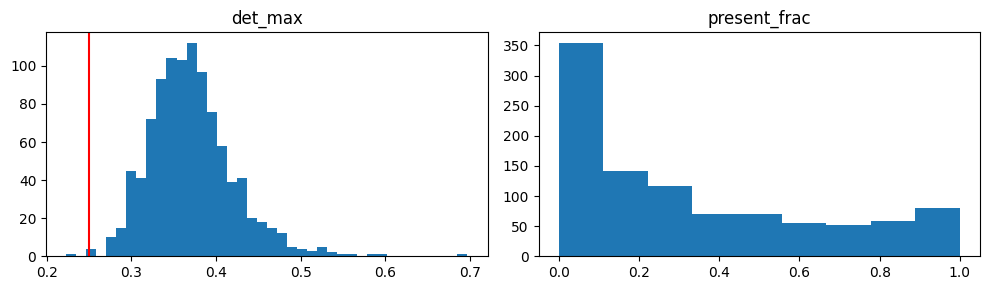

               count      mean   median
absent_pseudo                          
-1               681  0.657340  0.41400
 0               318  0.578845  0.44345
 1                 1  0.160200  0.16020


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

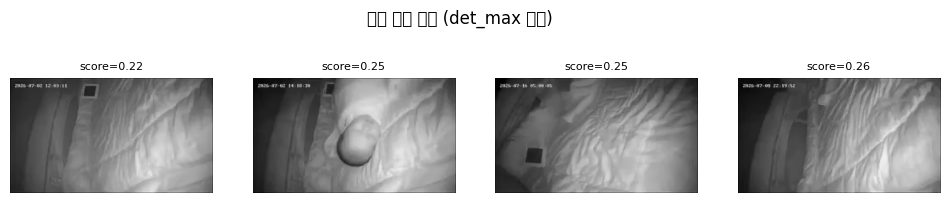

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

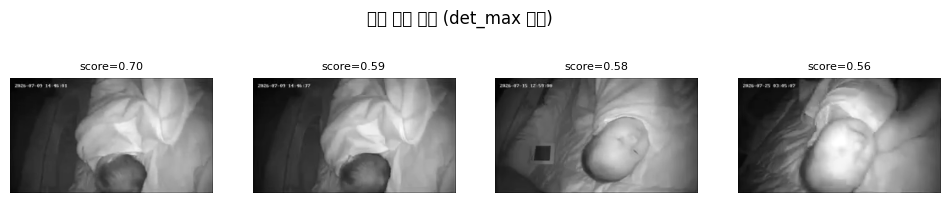

In [7]:
# 검증: 점수 분포 히스토그램 + mean_ydif 교차검증 + 극단 사례 프레임 표시
import pandas as pd, matplotlib.pyplot as plt, decord

res = pd.read_csv(OUT_CSV).drop_duplicates('file')
res = res[res['absent_pseudo'] != -9]
print('라벨 분포 (1=아기 없음, 0=있음, -1=불확실):')
print(res['absent_pseudo'].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(res['det_max'], bins=40); ax[0].axvline(ABSENT_TH, color='r'); ax[0].set_title('det_max')
ax[1].hist(res['present_frac'], bins=9); ax[1].set_title('present_frac')
plt.tight_layout(); plt.show()

# 교차검증: '아기 없음' 클립은 mean_ydif(프레임간 휘도차)도 낮아야 자연스러움
chk = res.merge(man[['file', 'mean_ydif']], on='file')
print(chk.groupby('absent_pseudo')['mean_ydif'].agg(['count', 'mean', 'median']))

def show_examples(df, title, k=4):
    fig, axes = plt.subplots(1, k, figsize=(12, 2.6)); fig.suptitle(title)
    for ax_, (_, r) in zip(axes, df.head(k).iterrows()):
        try:
            vr = decord.VideoReader(str(CLIPS / r['file']))
            ax_.imshow(vr[len(vr) // 2].asnumpy())
            ax_.set_title(f"score={r['det_max']:.2f}", fontsize=8)
        except Exception:
            ax_.set_title('로드 실패', fontsize=8)
        ax_.axis('off')
    plt.show()

show_examples(res.nsmallest(4, 'det_max'), '아기 없음 추정 (det_max 최저)')
show_examples(res.nlargest(4, 'det_max'), '아기 있음 추정 (det_max 최고)')